In [2]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# In round 1 of hyperparameter tuning we considered batch_size, learning rate, optimizer, and width. In round 2 
# we considered depth, dropout and threshold. 

with open('../data/hyperparameters/best_hyperparameters_round_2_1.txt', 'r') as file:
    lines = file.readlines()

data = []
for line in lines[1:]:
    line = line.strip().split('\t')
    try:
        hyperparams = ast.literal_eval(line[2])  # Use ast.literal_eval
    except (SyntaxError, ValueError):
        print(f"Error evaluating literal on line: {line}")
        continue

    data.append([float(line[1])] + list(hyperparams.values()))

columns = ['Metric Value'] + list(hyperparams.keys())
df = pd.DataFrame(data, columns=columns)
df = df.rename_axis('ID').reset_index()

df_sorted = df.sort_values(by='Metric Value', ascending=False)
df_sorted

,ID,Metric Value,depth,width,dropout,threshold,weight_decay
26,26,0.824602,22,84,0.0,0.60,0.010
49,49,0.820263,26,100,0.5,0.60,0.001
85,85,0.820219,30,244,0.3,0.45,0.001
52,52,0.818563,10,36,0.2,0.25,0.010
14,14,0.817717,10,4,0.3,0.30,0.100
...,...,...,...,...,...,...,...
32,32,0.800303,6,244,0.4,0.45,0.010
83,83,0.799545,30,20,0.2,0.25,0.010
92,92,0.799376,10,180,0.4,0.60,0.100
4,4,0.799038,46,100,0.3,0.25,0.000


In [3]:
    if hyperparam == 'lr' or hyperparam == 'width_1' or hyperparam == 'batch_size':
        plt.xscale('log') 

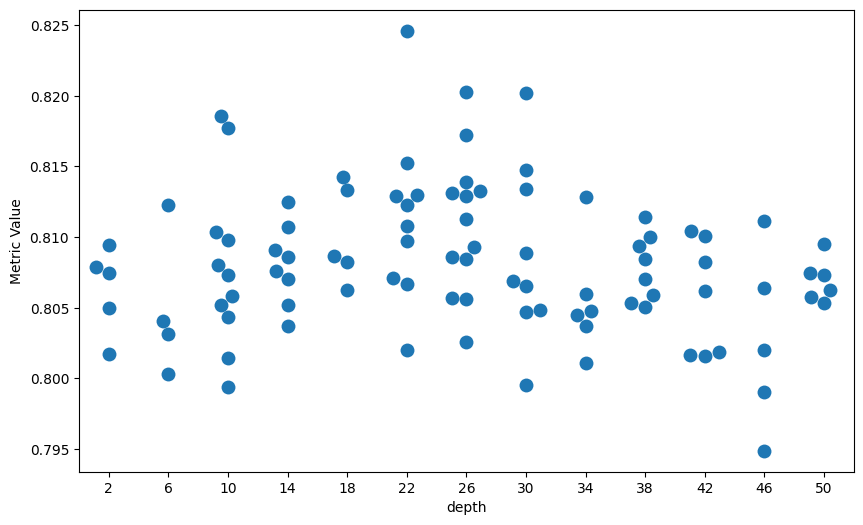

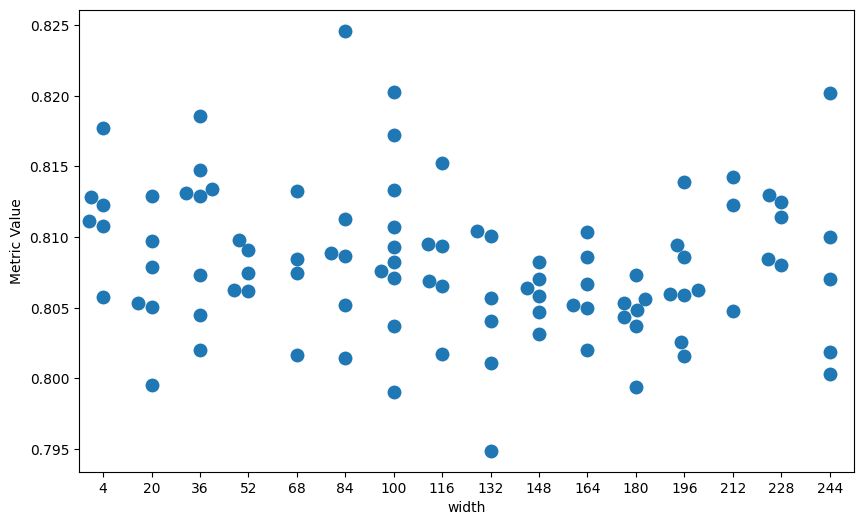

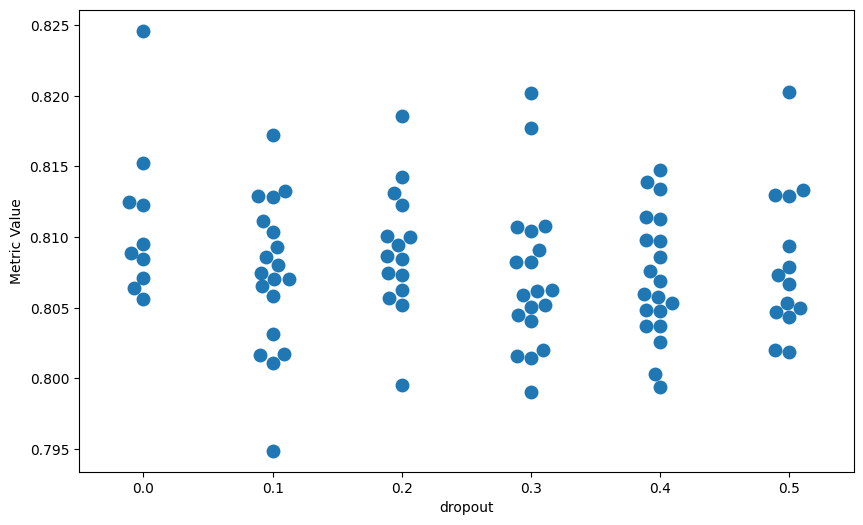

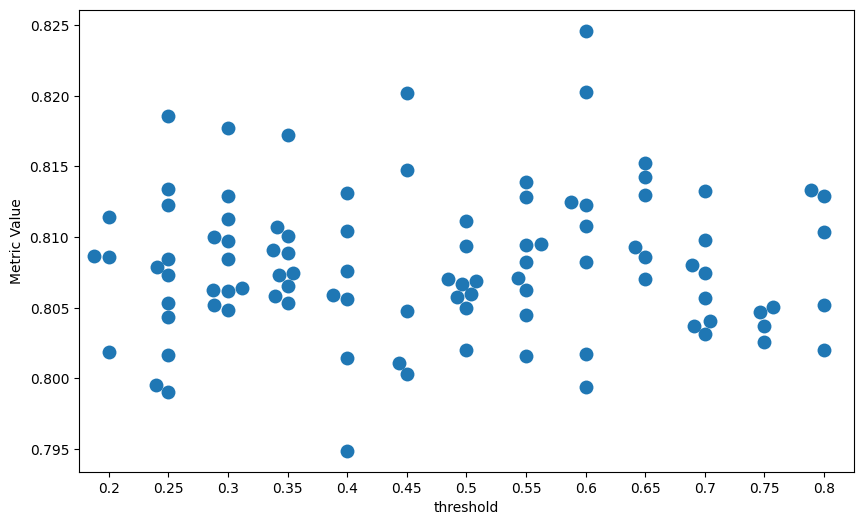

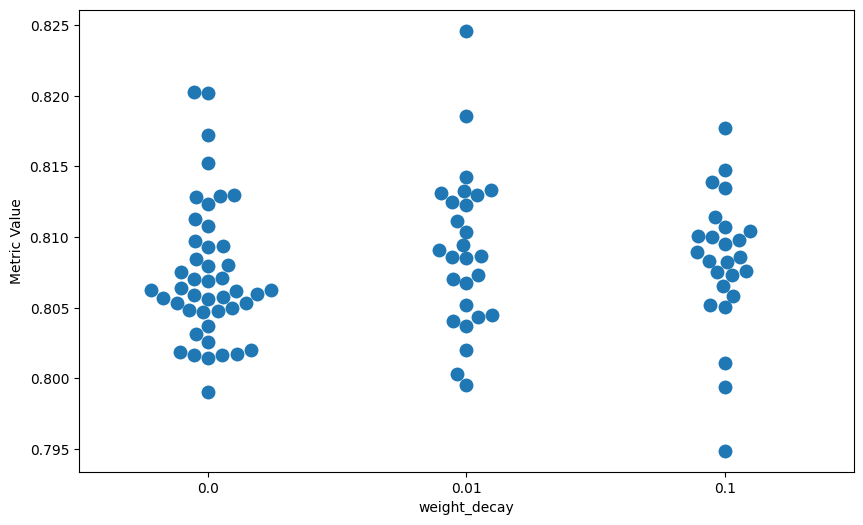

In [13]:
for hyperparam in list(hyperparams.keys()):
    rounded_values = df_sorted[hyperparam].round(2)  # Round to 2 decimal places
    df_rounded = pd.DataFrame({hyperparam: rounded_values, 'Metric Value': df_sorted['Metric Value']})
    plt.figure(figsize=(10, 6))
    sns.swarmplot(data=df_rounded, x=hyperparam, y='Metric Value', s=10)
    #plt.title(f'Swarm Plot of Metric Value vs {hyperparam}')
    plt.xlabel(hyperparam)
    plt.ylabel('Metric Value')
    plt.savefig(f"../plots/hyperparam_optimization/{hyperparam}_swarm_2.pdf", dpi=600) 
    plt.show()